In [17]:
%matplotlib widget

In [18]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [19]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/NGC3217/NGC3217_2/NGC-3217_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [20]:
image_cut = image[67:167, 0:1890]
image_error_cut = image_error[67:167, 0:1890]

In [21]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Text(0.5, 80.99305555555554, 'wavelenght')

In [22]:
z = 0.03191
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII_1 = 6548 * (1+z) 
l_NII_2 = 6583 * (1+z)
l_SII_1 = 6717 * (1+z)
l_SII_2 = 6731 * (1+z)
l_OIII_1 = 4959 * (1+z)
l_OIII_2 = 5007 * (1+z)

Text(0.5, 1.0, 'H$\\alpha$')

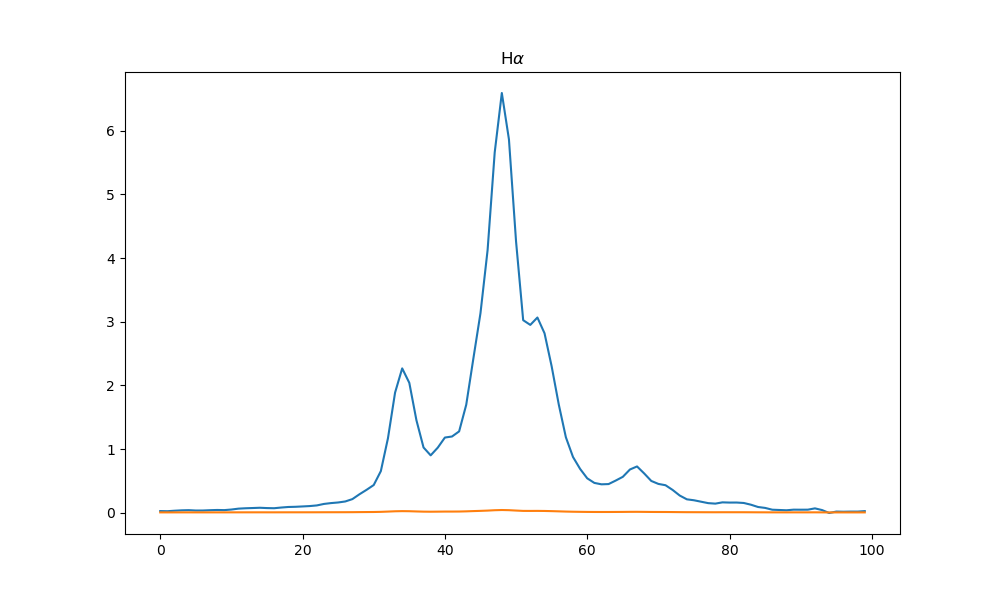

In [23]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')
#fit_HA = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Fit_code/Halpha_fit.csv", index_col=0)

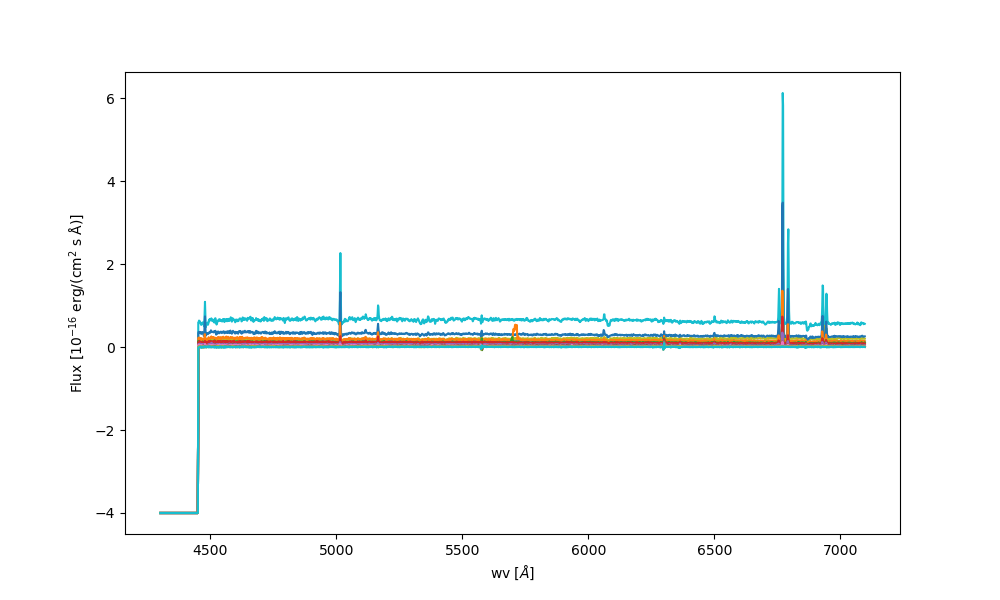

In [24]:
def extraction(x_axes, x_min, x_max, image_cut, image_error_cut):
    mask = (x_axes > x_min)*(x_axes < x_max)
    spectrum = np.sum(image_cut[mask, :], axis = 0)
    spectrum_err = np.sqrt(np.sum(image_error_cut[mask, :]**2, axis = 0))
    return spectrum, spectrum_err

os.makedirs('20ext', exist_ok=True)

spectra =  np.zeros((20, image_cut.shape[1]))
spectra_err = np.zeros((20, image_error_cut.shape[1]))
plt.figure(figsize=(10, 6))
for i in range(20):
    x_min = i * 5
    x_max = x_min + 5
    spectra[i], spectra_err[i] = extraction(x_axes, x_min, x_max, image_cut, image_error_cut)

    plt.plot(wv, spectra[i], label = f'spectrum {i+1}')
    plt.xlabel(r'wv [$\AA$]')
    plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
    
    spectrum_table = np.concatenate((wv.reshape(-1, 1), 
                                    spectra[i].reshape(-1, 1), spectra_err[i].reshape(-1, 1)), axis=1)
    filename = os.path.join('20ext', f'Spectrum_{i+1}.txt')  # Salva come spectrum_1.txt ... spectrum_20.txt
    np.savetxt(filename, spectrum_table)

## S/N continuum

In [25]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
mask_continuum_2 = (wv > 5300)*(wv < 5800)
mask_continuum_3 = (wv > 6400)*(wv < 6700)
# Liste per contenere i risultati
SNR = []
Signal = []
Noise = []
# Calcolo per ogni spettro
for i in range(20):  # Assumendo che peaks definisca il numero di spettri
    snr = []
    signal = []
    noise = []
    
    # Calcolo per continuum_1
    sig_1 = np.mean(spectra[i, mask_continuum_1])
    noise_1 = np.std(spectra[i, mask_continuum_1])
    snr_1 = sig_1 / noise_1
    
    # Calcolo per continuum_2  
    sig_2 = np.mean(spectra[i, mask_continuum_2])
    noise_2 = np.std(spectra[i, mask_continuum_2])
    snr_2 = sig_2 / noise_2
    
    # Calcolo per continuum_3
    sig_3 = np.mean(spectra[i, mask_continuum_3])
    noise_3 = np.std(spectra[i, mask_continuum_3])
    snr_3 = sig_3 / noise_3
    
    # Aggiunta ai risultati
    snr.extend([snr_1, snr_2, snr_3])
    signal.extend([sig_1, sig_2, sig_3])
    noise.extend([noise_1, noise_2, noise_3])
    
    SNR.append(snr)
    Signal.append(signal)
    Noise.append(noise)
    
# Conversione in array numpy e trasposizione
SNR_array = np.array(SNR).T  # Trasponi per avere continuum come righe
Signal_array = np.array(Signal).T
Noise_array = np.array(Noise).T

# Creazione del DataFrame
# Nomi delle colonne per ogni spettro
col_names = [f'Spectrum_{i+1}' for i in range(20)]
# Creazione di DataFrames separati per ogni metrica
df_snr = pd.DataFrame(SNR_array, 
                      columns=col_names,
                      index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_signal = pd.DataFrame(Signal_array, 
                         columns=col_names,
                         index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
df_noise = pd.DataFrame(Noise_array, 
                        columns=col_names,
                        index=['Continuum_1', 'Continuum_2', 'Continuum_3'])
# Combinazione in un unico DataFrame con MultiIndex per le colonne
df_combined = pd.concat([df_snr, df_signal, df_noise], 
                        keys=['SNR', 'Signal', 'Noise'], 
                        axis=1)
print("DataFrame SNR:")
print(df_snr)
print("\nDataFrame Signal:")
print(df_signal)
print("\nDataFrame Noise:")
print(df_noise)
print("\nDataFrame Combinato:")
print(df_combined)
# Salvataggio dei file
os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_snr = os.path.join('20ext', 'SNR_20ext_continuum.csv')
df_path_signal = os.path.join('20ext', 'Signal_20ext_continuum.csv')
df_path_noise = os.path.join('20ext', 'Noise_20ext_continuum.csv')
df_path_combined = os.path.join('20ext', 'Combined_20ext_continuum.csv')
# Assicurati che la directory esista
os.makedirs('20ext', exist_ok=True)
df_snr.to_csv(df_path_snr, float_format='%.3f')
df_signal.to_csv(df_path_signal, float_format='%.3f')
df_noise.to_csv(df_path_noise, float_format='%.3f')
df_combined.to_csv(df_path_combined, float_format='%.3f')
print(f"\nFile salvati in:")
print(f"- {df_path_snr}")
print(f"- {df_path_signal}")
print(f"- {df_path_noise}")
print(f"- {df_path_combined}")

DataFrame SNR:
             Spectrum_1  Spectrum_2  Spectrum_3  Spectrum_4  Spectrum_5  \
Continuum_1    1.279958    2.044410    3.030586    4.057586    6.098891   
Continuum_2    1.960844    2.537136    2.612085    3.630239    6.078102   
Continuum_3    2.591107    3.563339    4.362573    5.244086    7.744261   

             Spectrum_6  Spectrum_7  Spectrum_8  Spectrum_9  Spectrum_10  \
Continuum_1    8.951483   10.086150   11.343032   14.751024    22.125122   
Continuum_2    9.514299   12.524752   13.253595   14.066856    21.699189   
Continuum_3   10.722894   13.821344   14.809415   18.638942    27.972678   

             Spectrum_11  Spectrum_12  Spectrum_13  Spectrum_14  Spectrum_15  \
Continuum_1    18.490364    14.554716    11.669373    12.313008     8.179050   
Continuum_2    21.327802     3.692409     8.259259    13.795253     8.245508   
Continuum_3    23.000315    17.295876    14.473904    15.047482     9.298614   

             Spectrum_16  Spectrum_17  Spectrum_18  Spectr

## Redshift

In [26]:
from astropy.modeling import models
import astropy.units as u
from specutils import Spectrum
import astropy.units as u
from specutils.fitting import find_lines_threshold, fit_generic_continuum
from specutils.manipulation import noise_region_uncertainty
from astropy.nddata import StdDevUncertainty
from astropy.modeling.fitting import LinearLSQFitter

Spettro 1
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 8
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
5098.4599999997645   emission               437
 4832.059999999843 absorption               257
5006.6999999997915 absorption               375
 5573.539999999624 absorption               758
 5577.979999999623 absorption               761
 6297.259999999411 absorption              1247
 6360.899999999392 absorption              1290
 6550.339999999336 absorption              1418
Spettro 2
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 23
   line_center     line_type  line_center_index
     Angstrom                                  
------------------ ---------- -----------------
 5506.939999999644   emission               713
 5570.579999999625   emission               756
  6300.21999999941   emission              1249
  6979.53999999921   emission              17


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 4
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 21
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
4615.979999999907   emission               111
 6300.21999999941   emission              1249
6770.859999999271   emission              1567
6791.579999999265   emission              1581
 6978.05999999921   emission              1707
4663.339999999893 absorption               143
4883.859999999828 absorption               292
5135.459999999754 absorption               462
5243.499999999722 absorption               535
5401.859999999675 absorption               642
5573.539999999624 absorption               758
5577.979999999623 absorption               761
6162.579999999451 absorption              1156
6297.259999999411 absorption              1247
6303.179999999409 absorption              1251
6360.899999999392 absorption              1290
6455.619999999364 absorption         


If you want to suppress this warning either type 'specutils.conf.do_continuum_function_check = False' or see http://docs.astropy.org/en/stable/config/#adding-new-configuration-items for other ways to configure the warning. [specutils.analysis.flux]


Spettro 18
Numero di righe trovate (tutto lo spettro, wv > 4451 Å): 19
   line_center    line_type  line_center_index
     Angstrom                                 
----------------- ---------- -----------------
4931.219999999814   emission               324
5166.539999999744   emission               483
 6300.21999999941   emission              1249
6769.379999999272   emission              1566
4476.859999999948 absorption                17
5028.899999999785 absorption               390
5036.299999999783 absorption               395
5573.539999999624 absorption               758
5579.459999999623 absorption               762
6053.059999999483 absorption              1082
6285.419999999414 absorption              1239
6297.259999999411 absorption              1247
6303.179999999409 absorption              1251
6360.899999999392 absorption              1290
6495.579999999352 absorption              1381
6501.499999999351 absorption              1385
6529.619999999342 absorption        

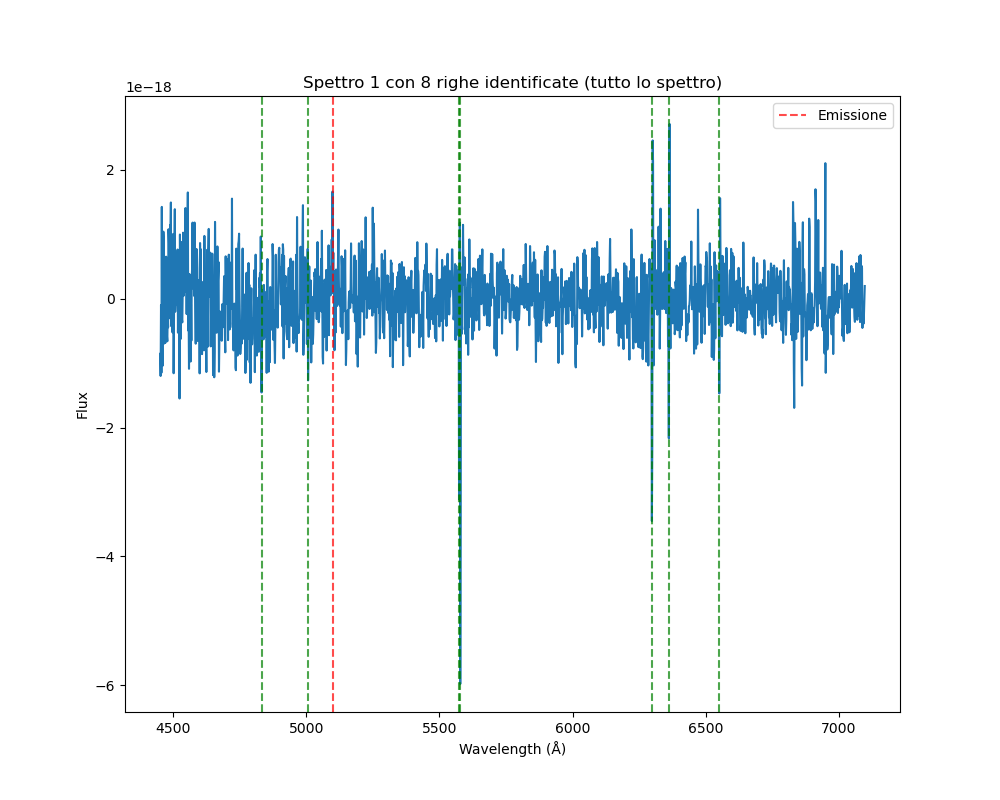

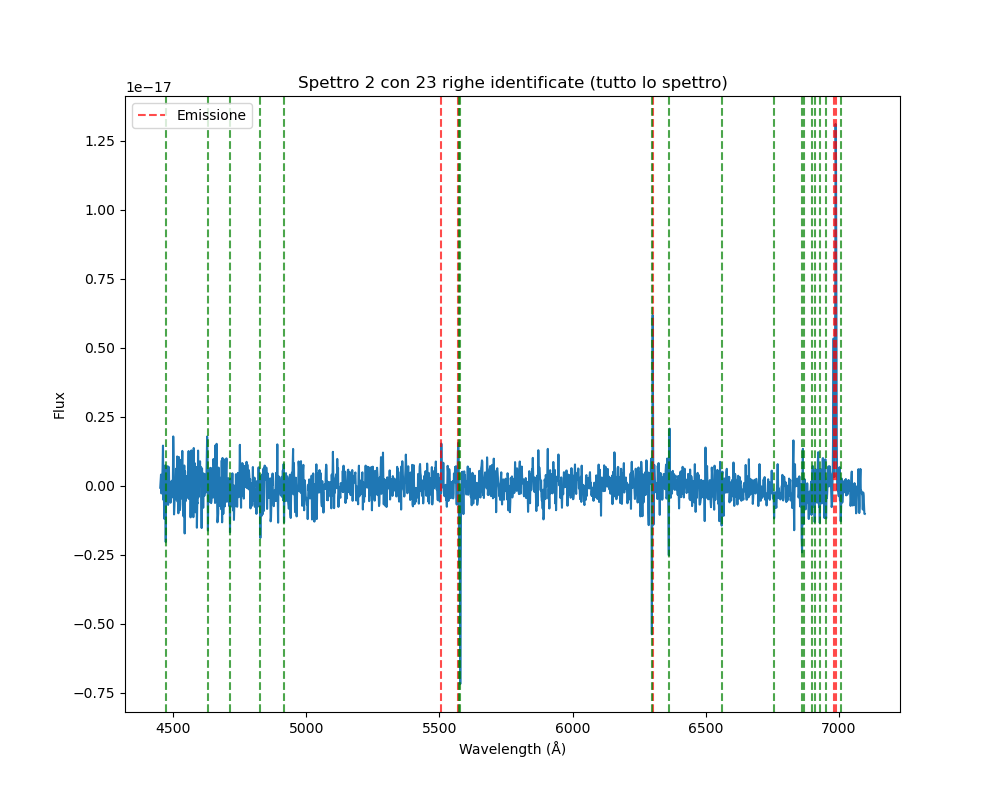

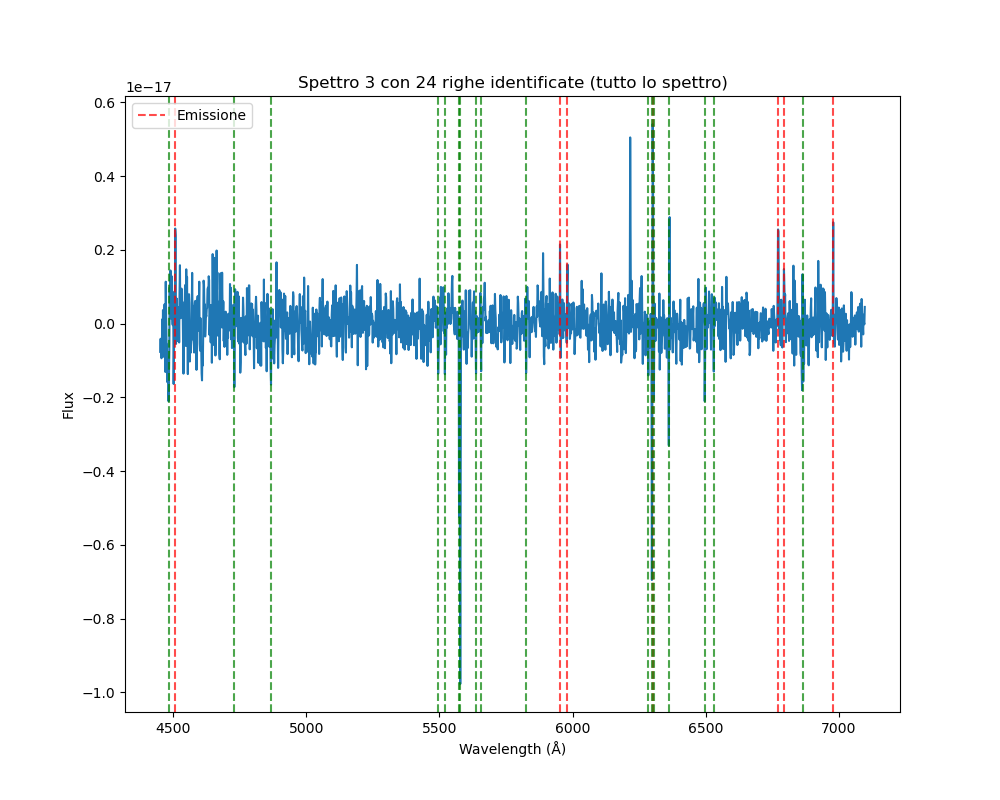

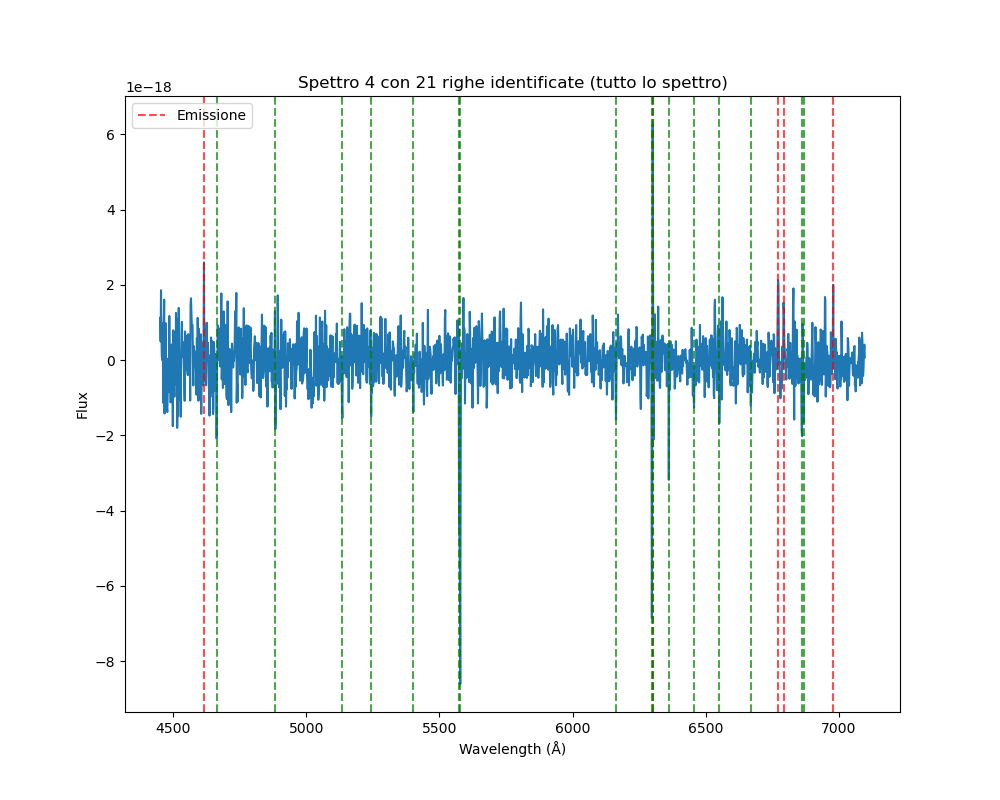

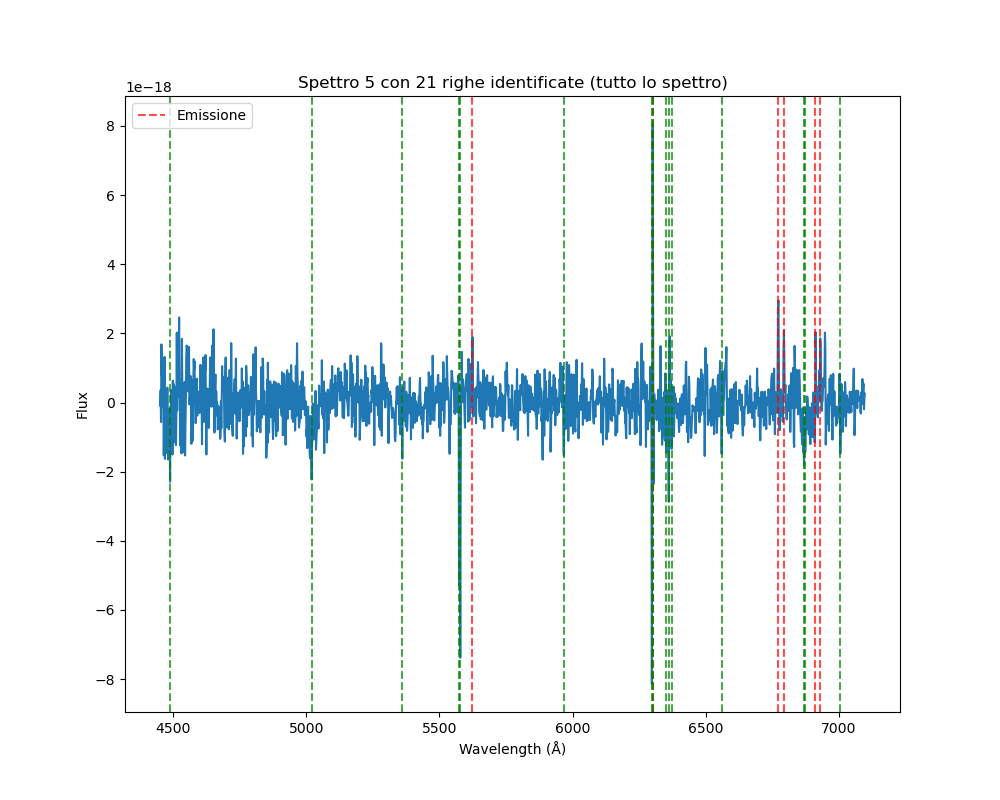

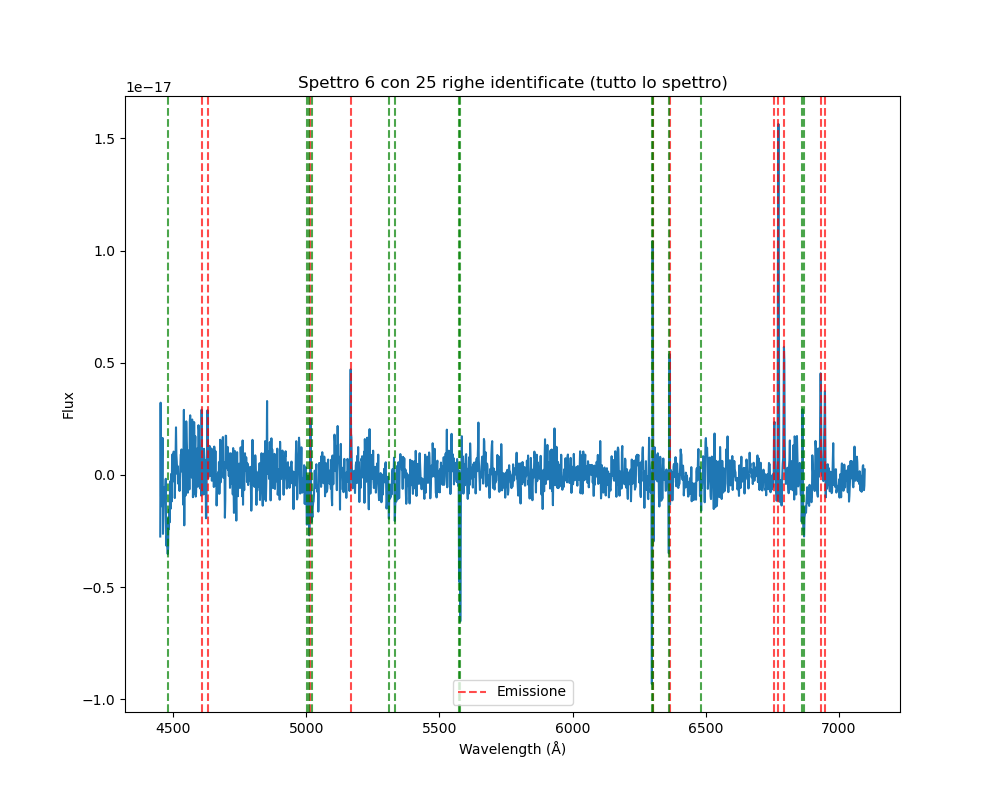

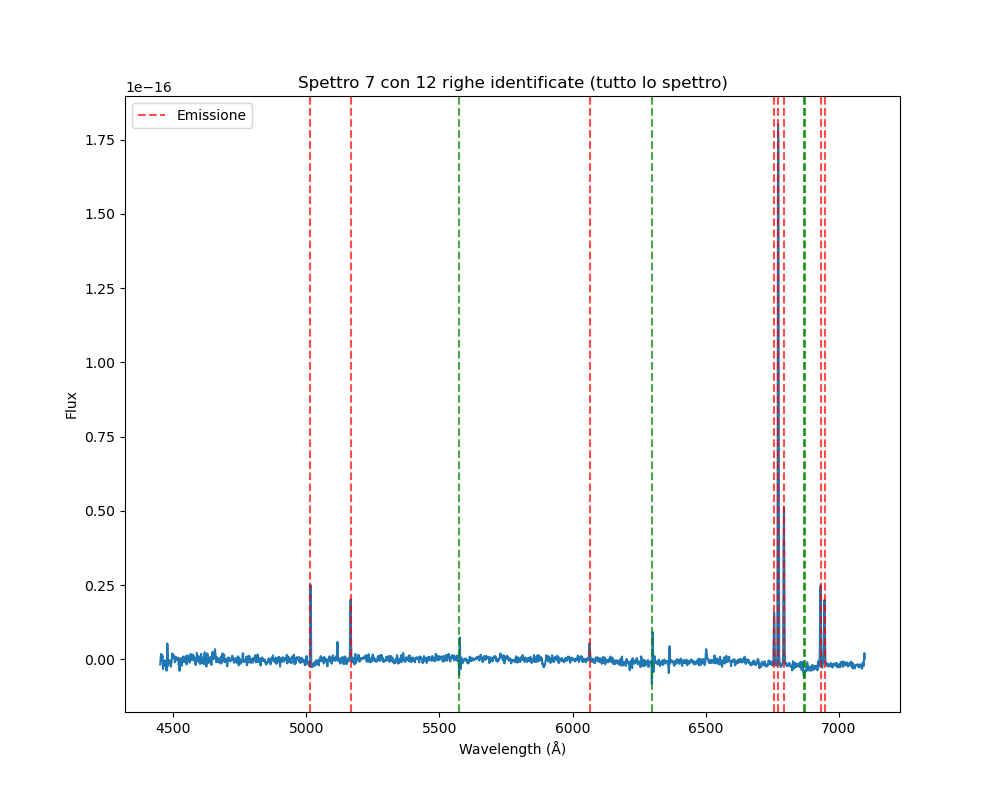

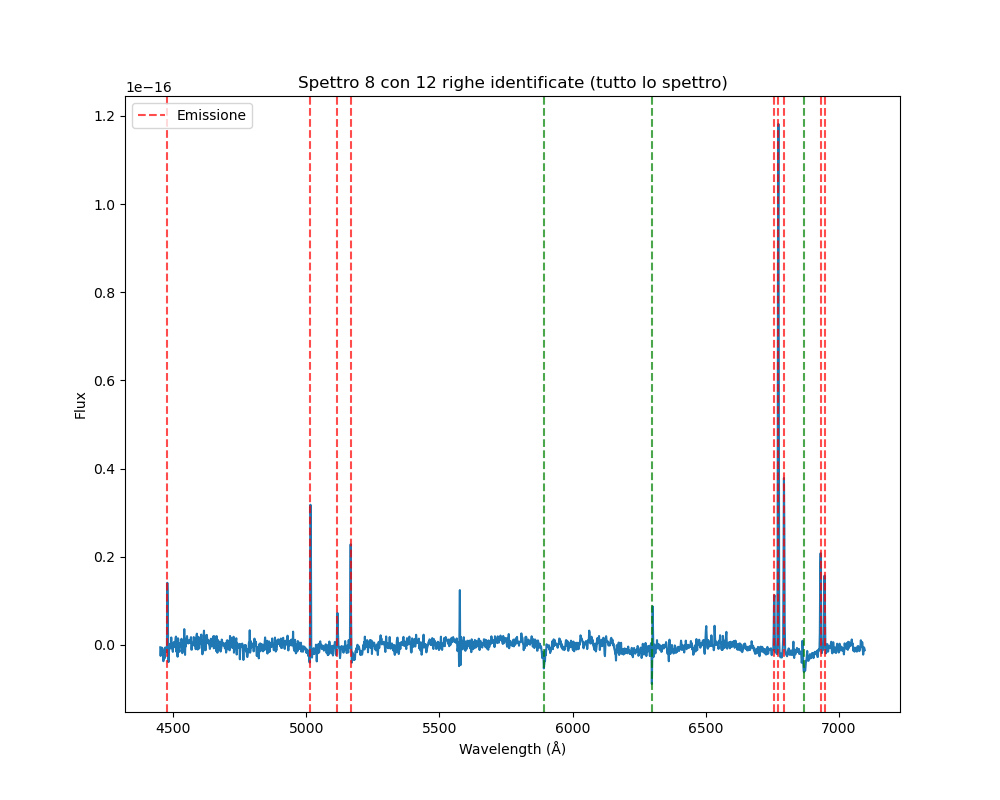

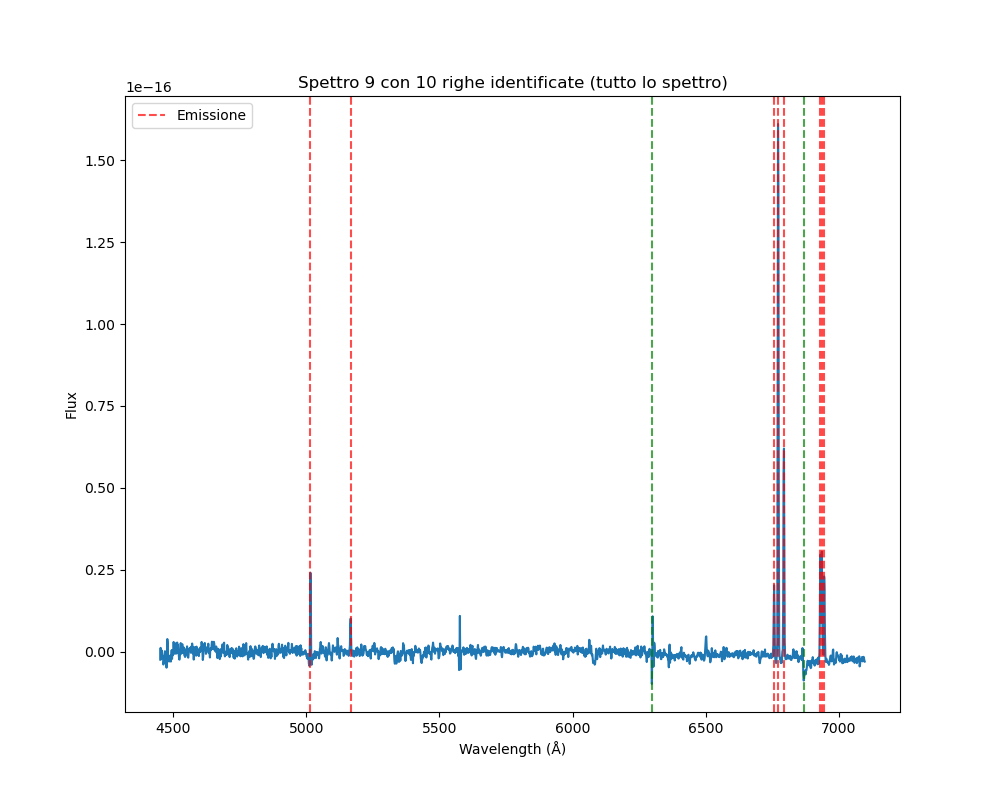

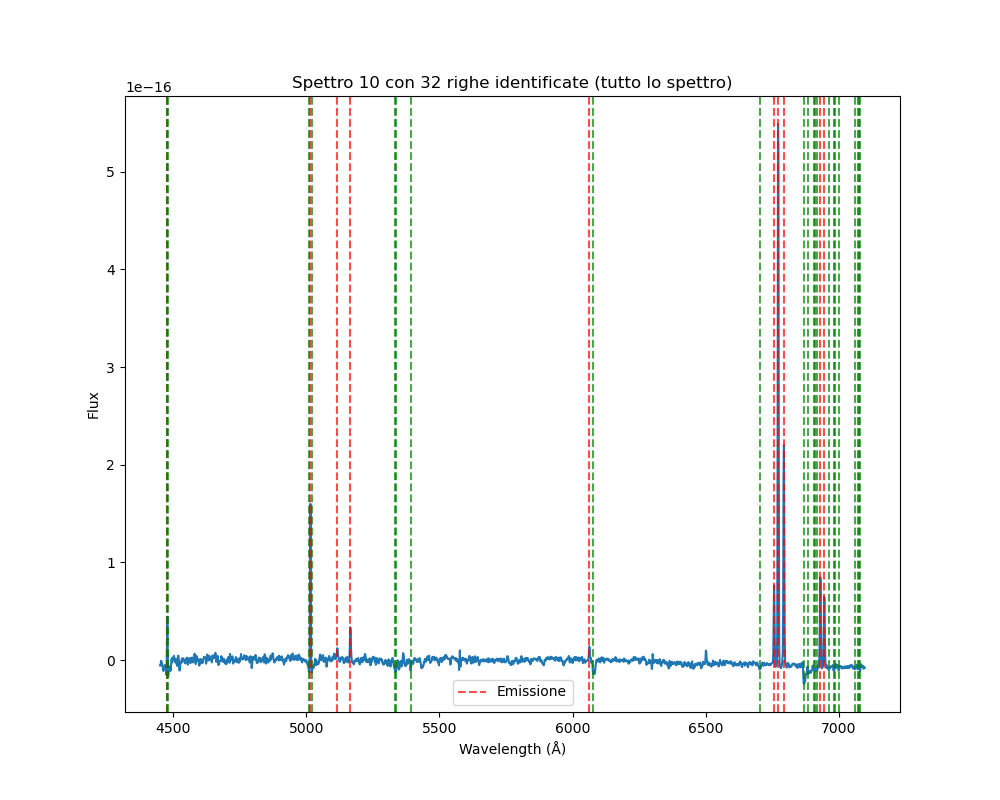

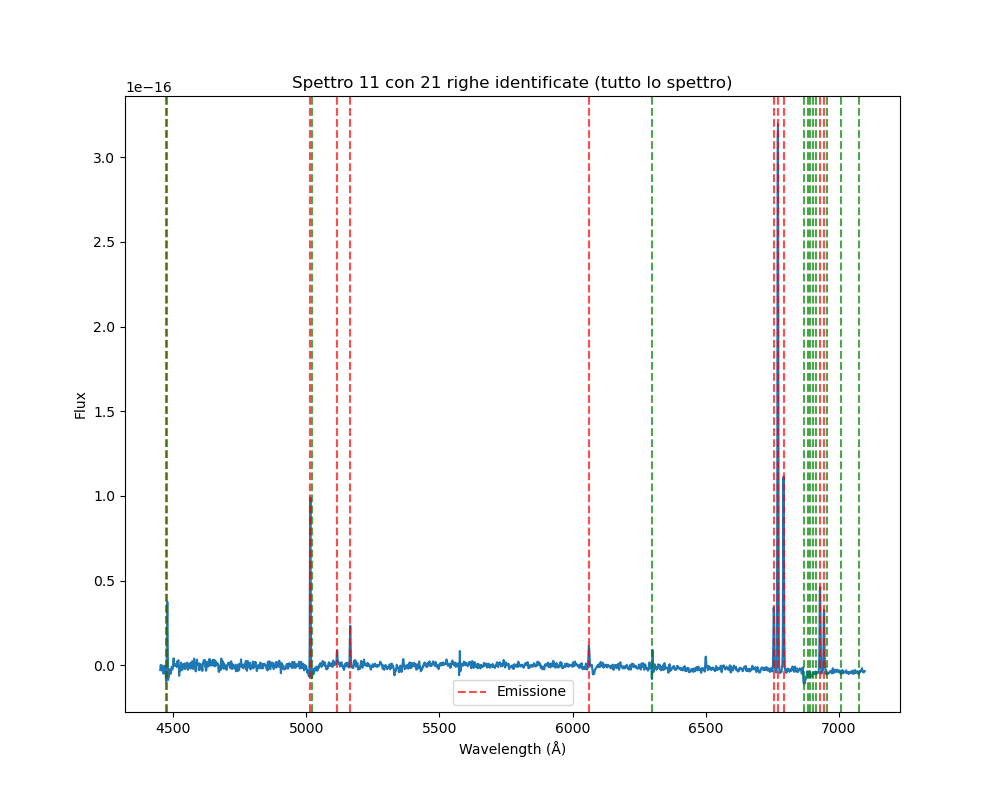

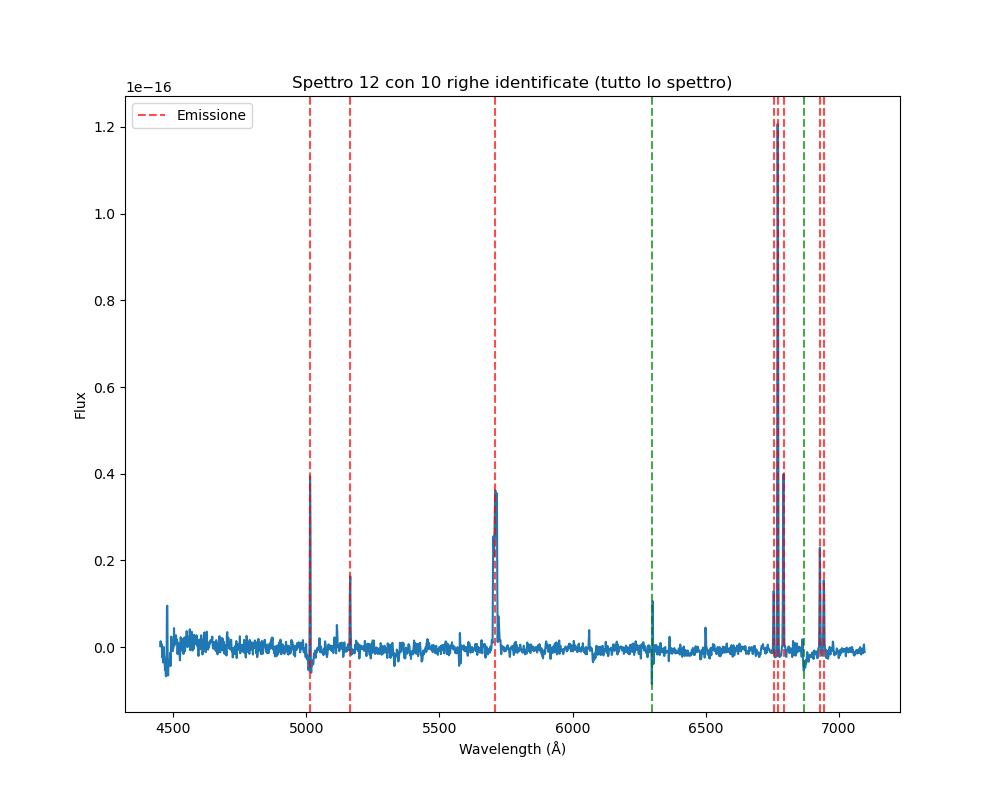

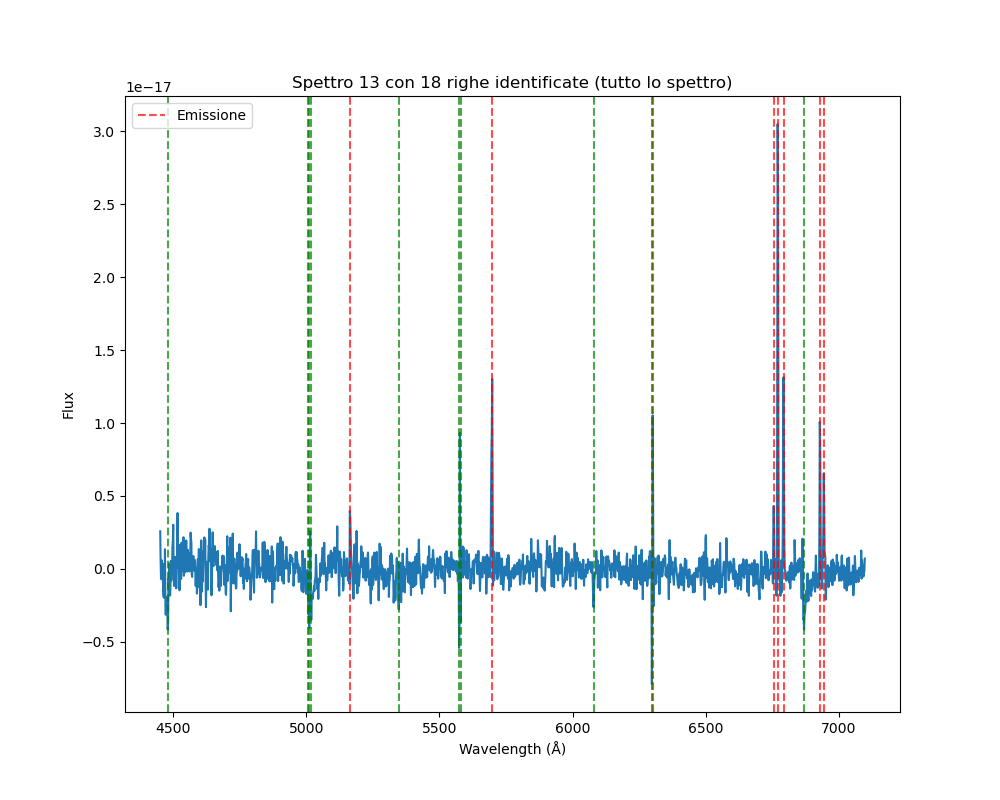

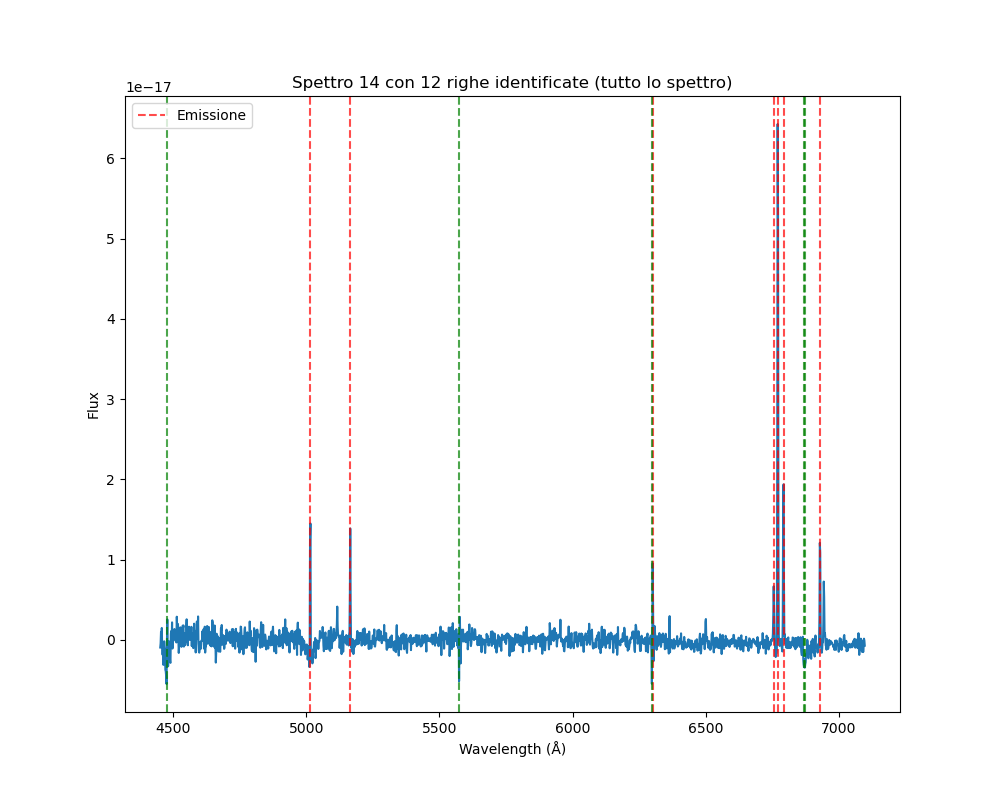

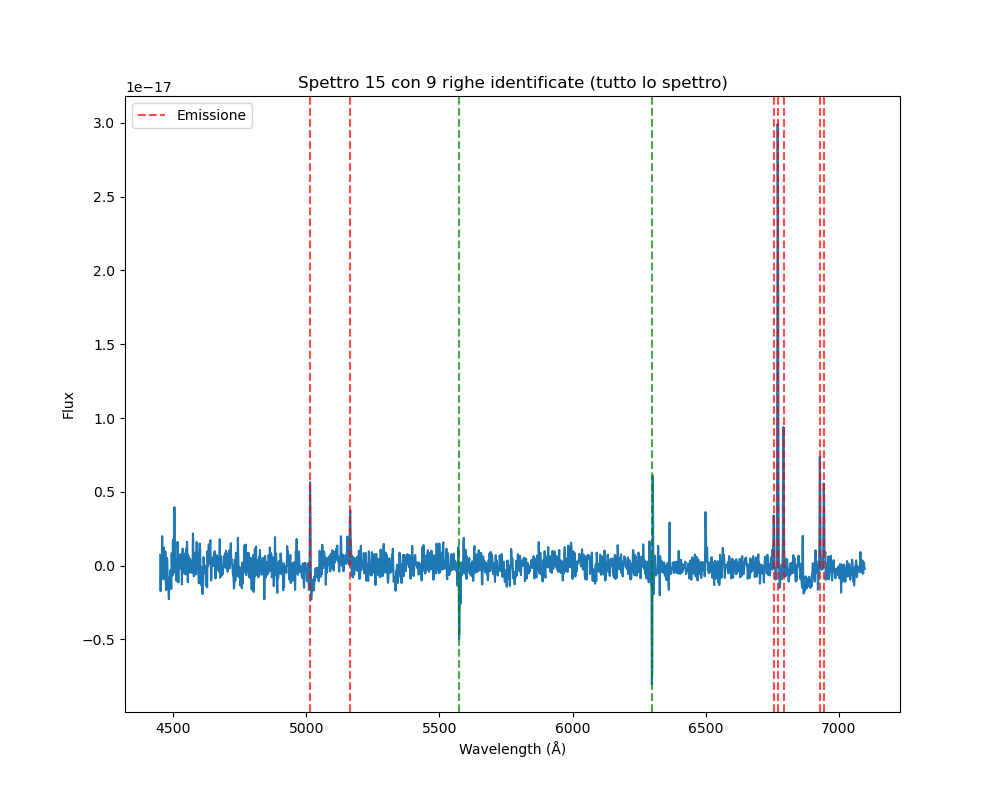

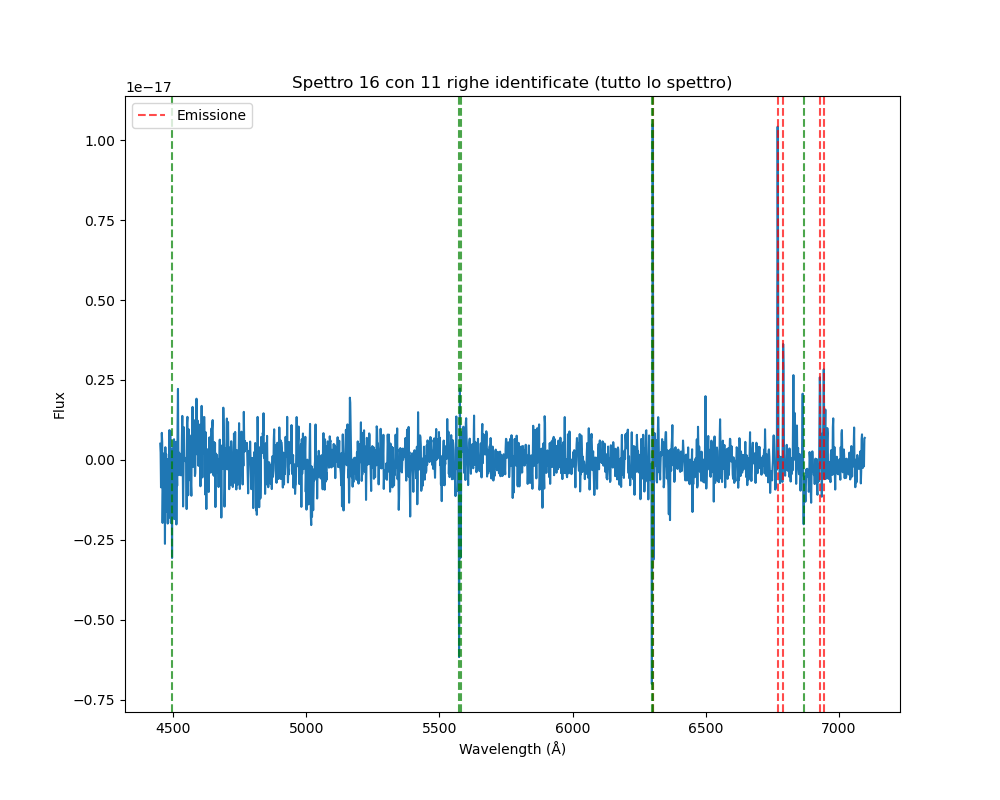

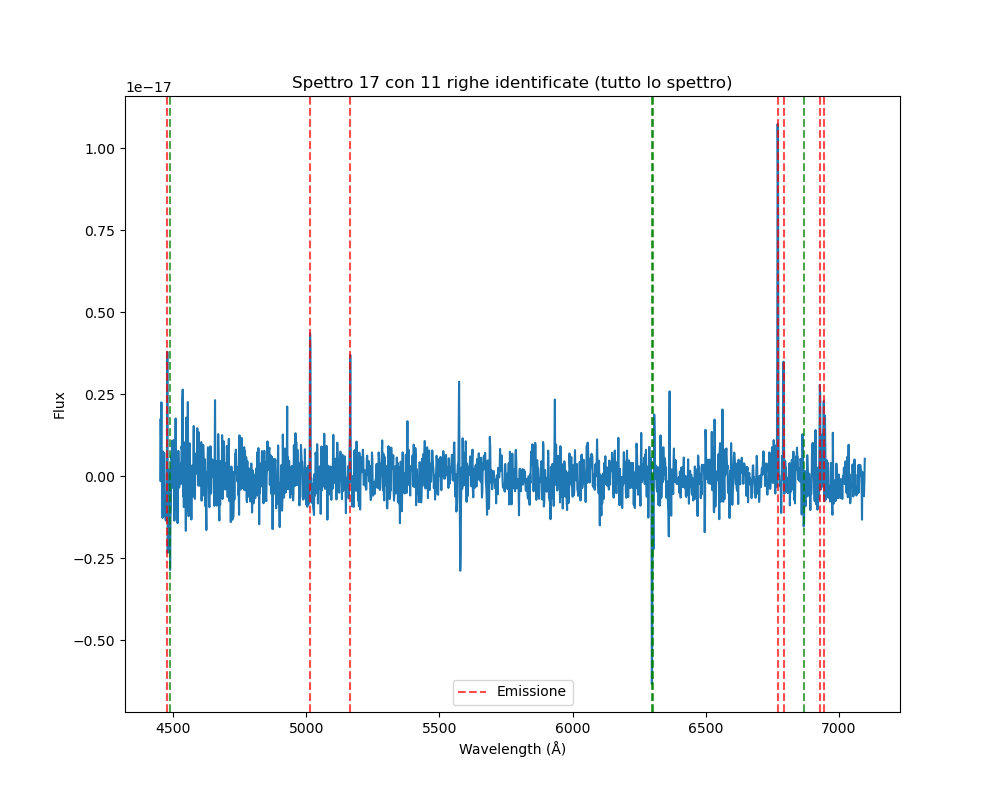

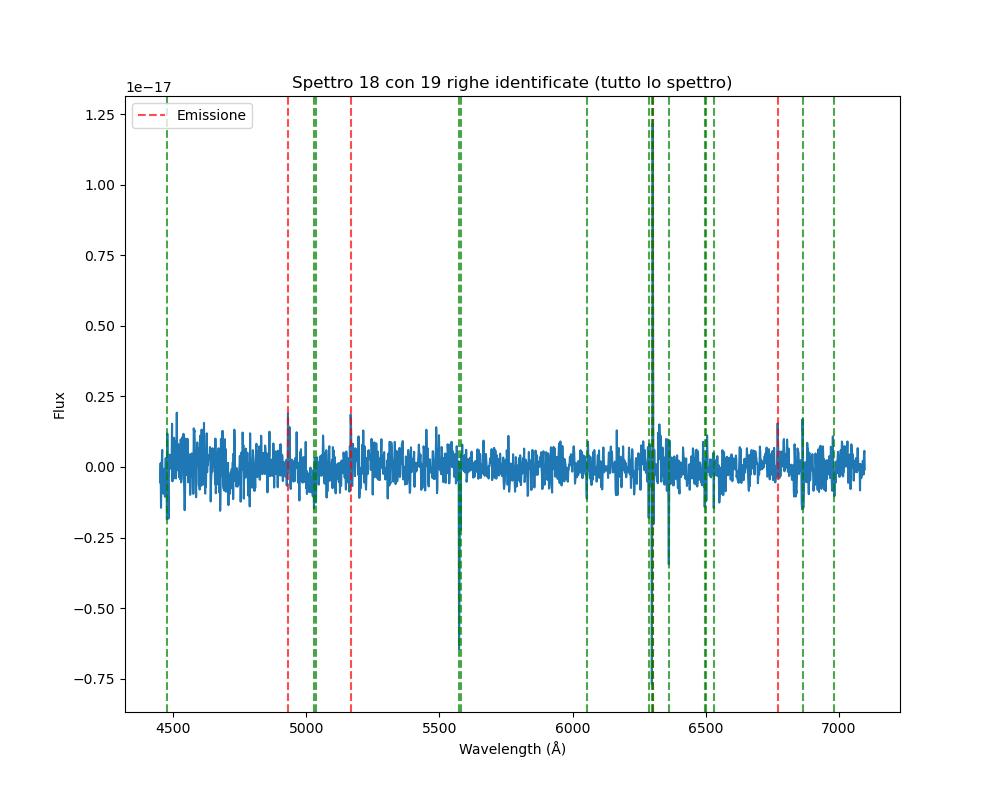

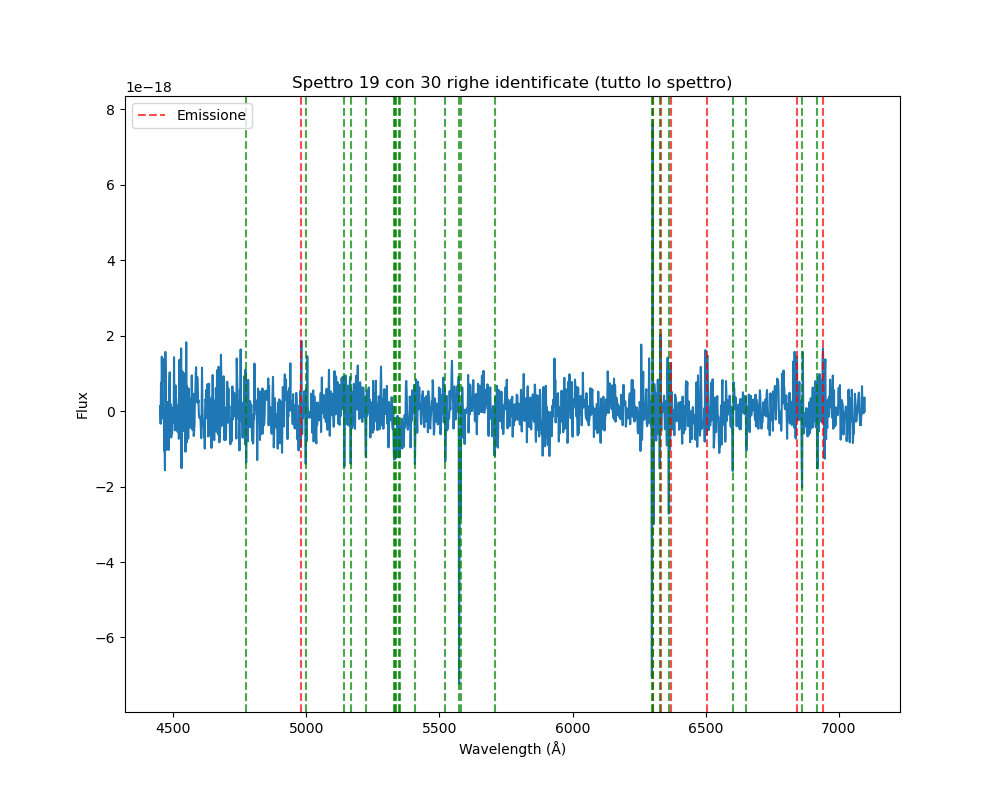

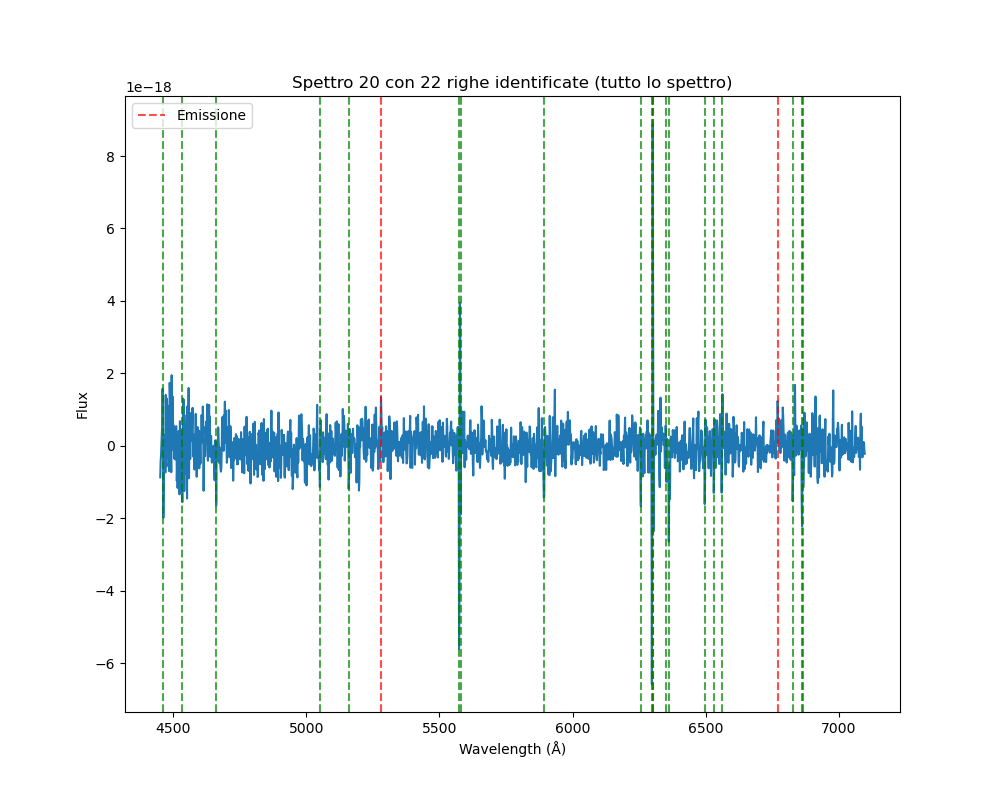

In [33]:
all_lines = []
noise_factor = [3, 3, 3, 3, 3, 3, 7, 7, 7, 7, 6, 8, 4, 5, 5, 4, 4, 3, 3, 3]
# Filtra per lunghezze d'onda > 4451 Å
wv_mask = wv > 4451
wv_filtered = wv[wv_mask]

for i in range(20):
    # Applica il filtro anche agli spettri
    spectra_filtered = spectra[i][wv_mask]
    spectra_err_filtered = spectra_err[i][wv_mask]
    
    # Usa lo spettro filtrato per il fitting del continuum
    spectrum = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux = spectra_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom),  
        uncertainty = StdDevUncertainty(spectra_err_filtered * 1e-16 *u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    g1_fit = fit_generic_continuum(spectrum, fitter=LinearLSQFitter())
    y_continuum_fitted = g1_fit(wv_filtered * u.Angstrom)
    
    flux_continuum_subtracted = spectrum.flux - y_continuum_fitted
    
    # Crea lo spettro per TUTTO il range filtrato (senza ritagliare i bordi)
    spectrum_no_continuum_full = Spectrum(
        spectral_axis=wv_filtered * u.Angstrom,
        flux=flux_continuum_subtracted,
        uncertainty=StdDevUncertainty(spectra_err_filtered * 1e-16 * u.erg / (u.cm**2 * u.s * u.Angstrom))
    )
    
    # Trova le righe su TUTTO lo spettro filtrato (senza escludere i bordi)
    lines = find_lines_threshold(spectrum_no_continuum_full, noise_factor = noise_factor[i])
    print('Spettro', i+1)
    print(f"Numero di righe trovate (tutto lo spettro, wv > 4451 Å): {len(lines)}")
    print(lines)
    
    f3, ax3 = plt.subplots(figsize=(10,8))
    ax3.plot(wv_filtered, flux_continuum_subtracted.value)
    
    if len(lines) < 50:  # Solo se non sono troppe
        for line_pos in lines['line_center']:
            # Trova l'indice corrispondente nel flux per determinare il tipo di riga
            line_idx = np.argmin(np.abs(wv_filtered - line_pos.value))
            
            # Determina se è emissione (positiva) o assorbimento (negativa)
            if flux_continuum_subtracted[line_idx].value > 0:
                # Riga di emissione - colore rosso
                ax3.axvline(x=line_pos.value, color='red', alpha=0.7, linestyle='--', 
                           label='Emissione' if line_pos == lines['line_center'][0] else "")
            else:
                # Riga di assorbimento - colore verde
                ax3.axvline(x=line_pos.value, color='green', alpha=0.7, linestyle='--',
                           label='Assorbimento' if line_pos == lines['line_center'][0] else "")
    
    ax3.legend()
    ax3.set_title(f"Spettro {i+1} con {len(lines)} righe identificate (tutto lo spettro)")
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Flux')
    all_lines.append(lines)

In [52]:
#reference wv in air
l_Hgam = 4340.5
l_HA = 6562.8
l_HB = 4861.3
l_NII_1 = 6548.1
l_NII_2 = 6583.4
l_SII_1 = 6717.0
l_SII_2 = 6731.3
l_OIII_1 = 4958.9
l_OIII_2 = 5006.8
l_He_1 = 5875.6
l_OI = 6300.3

lines_3 = [l_HA, l_NII_2]
lines_4 = [l_HA, l_NII_2]
lines_5 = [l_HA, l_NII_2, l_SII_1]
lines_6 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_7 = [l_HB, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_8 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_9 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_10 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_11 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_12 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_13 = [l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_14 = [l_HB, l_OIII_2, l_NII_1, l_HA, l_NII_2, l_SII_1]
lines_15 = [l_Hgam, l_HB, l_OIII_1, l_OIII_2, l_He_1, l_OI, l_NII_1, l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_16 = [l_HA, l_NII_2, l_SII_1, l_SII_2]
lines_17 = [l_Hgam, l_HB, l_OIII_2, l_HA, l_NII_2, l_SII_1, l_SII_2]

lines_spectrum_3 = [6770.859999999271, 6793.059999999265]
lines_spectrum_4 = [6770.859999999271, 6791.579999999265]
lines_spectrum_5 = [6772.339999999271, 6793.059999999265, 6929.2199999992245]
lines_spectrum_6 = [5015.579999999789, 5166.539999999744, 6757.539999999275, 6772.339999999271, 6793.059999999265, 6930.699999999224, 6946.979999999219]
lines_spectrum_7 = [5015.579999999789,  5166.539999999744,   6063.41999999948, 6756.0599999992755,  6770.859999999271,  6793.059999999265,  6930.699999999224,   6945.49999999922]
lines_spectrum_8 = all_lines[7]['line_center'] 
lines_spectrum_9 = [5015.579999999789, 5166.539999999744, 6756.0599999992755, 6770.859999999271, 6793.059999999265, 6929.2199999992245, 6944.01999999922]
lines_spectrum_10 = all_lines[9]['line_center']
lines_spectrum_11 = all_lines[10]['line_center'] 
lines_spectrum_12 = [5014.099999999789,  5165.059999999745,  6754.579999999276,  6769.379999999272,  6791.579999999265,  6927.739999999225, 6942.5399999992205]
lines_spectrum_13 = [5163.579999999745, 6754.579999999276, 6769.379999999272, 6791.579999999265, 6927.739999999225, 6942.5399999992205]
lines_spectrum_14 = [5015.579999999789, 5165.059999999745, 6754.579999999276, 6769.379999999272, 6791.579999999265, 6927.739999999225]
lines_spectrum_15 = [4478.339999999947, 5017.0599999997885,  5116.219999999759, 5166.539999999744, 6063.41999999948,  6501.499999999351, 6756.0599999992755,  6772.339999999271,  6793.059999999265,  6930.699999999224,   6945.49999999922]
lines_spectrum_16 = [6769.379999999272, 6790.0999999992655, 6927.739999999225, 6942.5399999992205]
lines_spectrum_17 = [4478.339999999947, 5014.099999999789, 5165.059999999745, 6769.379999999272,  6791.579999999265, 6927.739999999225, 6942.5399999992205 ]

def redshift(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i].value / lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std
    
def redshift_hand(lines, lines_spectrum):
    z = np.zeros(len(lines))
    for i in range(len(lines)):
        z[i] = lines_spectrum[i]/ lines[i] - 1
    z_mean = np.mean(z)
    z_std = np.std(z)
    return z_mean, z_std

z_3_mean, z_3_std = redshift_hand(lines_3, lines_spectrum_3)
z_4_mean, z_4_std = redshift_hand(lines_4, lines_spectrum_4)
z_5_mean, z_5_std = redshift_hand(lines_5, lines_spectrum_5) 
z_6_mean, z_6_std = redshift_hand(lines_6, lines_spectrum_6) 
z_7_mean, z_7_std = redshift_hand(lines_7, lines_spectrum_7) 
z_8_mean, z_8_std = redshift(lines_8, lines_spectrum_8) 
z_9_mean, z_9_std = redshift_hand(lines_9, lines_spectrum_9) 
z_10_mean, z_10_std = redshift(lines_10, lines_spectrum_10) 
z_11_mean, z_11_std = redshift(lines_11, lines_spectrum_11) 
z_12_mean, z_12_std = redshift_hand(lines_12, lines_spectrum_12) 
z_13_mean, z_13_std = redshift_hand(lines_13, lines_spectrum_13) 
z_14_mean, z_14_std = redshift_hand(lines_14, lines_spectrum_14) 
z_15_mean, z_15_std = redshift_hand(lines_15, lines_spectrum_15)
z_16_mean, z_16_std = redshift_hand(lines_16, lines_spectrum_16) 
z_17_mean, z_17_std = redshift_hand(lines_17, lines_spectrum_17)

z = [np.nan, np.nan, np.nan, z_4_mean, z_5_mean, z_6_mean, z_7_mean, z_8_mean, z_9_mean, z_10_mean, z_11_mean, z_12_mean, z_13_mean, z_14_mean, z_15_mean, z_16_mean, z_17_mean, np.nan, np.nan, np.nan]
z_err = [np.nan, np.nan, np.nan, z_4_std, z_5_std, z_6_std, z_7_std, z_8_std, z_9_std, z_10_std, z_11_std, z_12_std, z_13_std, z_14_std, z_15_std, z_16_std, z_17_std, np.nan, np.nan, np.nan]

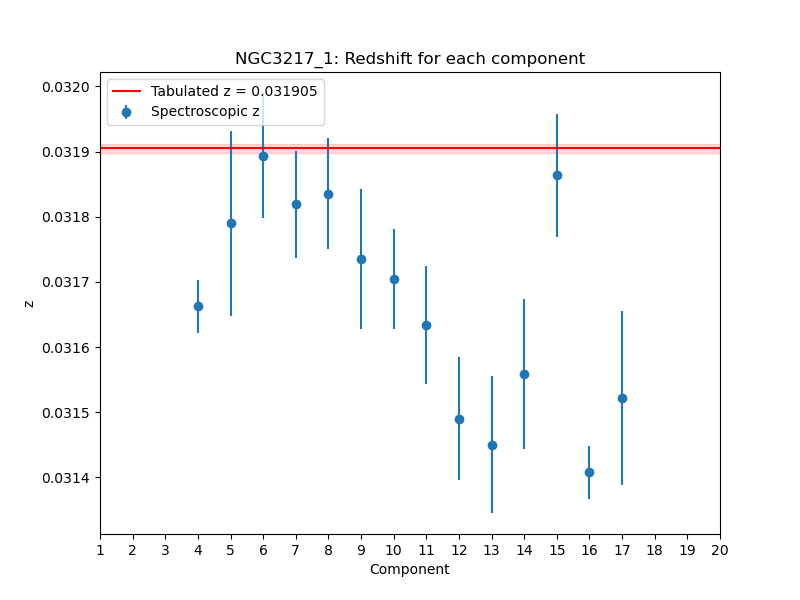

In [53]:
plt.figure(figsize=(8, 6))
comp = np.arange(1, 21, 1)
plt.errorbar(comp, z, z_err, ls='none', marker = 'o', label = 'Spectroscopic z')
plt.xlabel('Component')
plt.ylabel('z')
plt.xticks(comp)
plt.axhline(0.031905, color = 'red', label = 'Tabulated z = 0.031905')
plt.axhspan(0.031905-7.32e-6, 0.031905+7.32e-6, alpha=0.15, color='red', zorder=1)
plt.title('NGC3217_1: Redshift for each component')
plt.legend(loc = 'upper left')
plt.savefig('Redshift_NGC3217_1', bbox_inches='tight')

red_table = np.column_stack((z, z_err))
np.savetxt('redshift.txt', red_table, header='redshift redshift_error', fmt='%.5f',delimiter='\t')

## S/N emission lines 

In [54]:
def SNR_line(wv, wv_line, spectrum): 
    left_region = (wv > wv_line-15)*(wv < wv_line-5) 
    right_region = (wv > wv_line+5)*(wv < wv_line+15) 
    clean_mask = left_region | right_region

    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectrum[mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise
    
def SNR_OIII_line(wv, OIII_1, OIII_2, wv_line, spectrum):
    
    left_region = (wv > OIII_1-15)*(wv < OIII_1-5) 
    right_region = (wv > OIII_2+5)*(wv < OIII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 
    
def SNR_SII_line(wv, SII_1, SII_2, wv_line, spectrum):
    
    left_region = (wv > SII_1-15)*(wv < SII_1-5) 
    right_region = (wv > SII_2+5)*(wv < SII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def SNR_HA_NII(wv, NII_1, NII_2, wv_line, spectrum):
    
    left_region = (wv > NII_1-15)*(wv < NII_1-5) 
    right_region = (wv > NII_2+5)*(wv < NII_2+15) 
    clean_mask = left_region | right_region
    
    mask = (wv > wv_line-4)*(wv < wv_line+4)
    wv_bin = np.array(np.where(mask == True))
    flux = spectra[i, mask] - np.mean(spectrum[clean_mask])
    signal = (np.trapz(flux, wv[mask]))
    noise = np.std(spectrum[clean_mask] - np.mean(spectrum[clean_mask]))*1.48*np.sqrt(wv_bin.shape[1]) #std*delta(wv)*number of A under the line
    SNR = signal/noise
    return SNR, signal, noise 

def save_spectral_data(snr, signal, noise, line_name, output_dir='20ext', num_spectra=20):
    
    data = np.concatenate([
        np.array(snr).reshape(-1, 1),
        np.array(signal).reshape(-1, 1),
        np.array(noise).reshape(-1, 1)
    ], axis=1)

    df = pd.DataFrame(
        data, 
        columns=['SNR', 'Signal', 'Noise'],
        index=[f'Spettro_{i+1}' for i in range(num_spectra)]
    )
    
    df_path = os.path.join(output_dir, f'SNR_{line_name}.csv')
    df.to_csv(df_path, float_format='%.3f')
    print(df)
    return df_path

In [55]:
SNR_HB = np.zeros(20)
signal_HB = np.zeros(20)
noise_HB = np.zeros(20)
SNR_SII_1 = np.zeros(20)
signal_SII_1 = np.zeros(20)
noise_SII_1 = np.zeros(20)
SNR_SII_2 = np.zeros(20)
signal_SII_2 = np.zeros(20)
noise_SII_2 = np.zeros(20)
SNR_NII_1 = np.zeros(20)
signal_NII_1 = np.zeros(20)
noise_NII_1 = np.zeros(20)
SNR_NII_2 = np.zeros(20)
signal_NII_2 = np.zeros(20)
noise_NII_2 = np.zeros(20)
SNR_HA = np.zeros(20)
signal_HA = np.zeros(20)
noise_HA = np.zeros(20)
SNR_OIII_1 = np.zeros(20)
signal_OIII_1 = np.zeros(20)
noise_OIII_1 = np.zeros(20)
SNR_OIII_2 = np.zeros(20)
signal_OIII_2 = np.zeros(20)
noise_OIII_2 = np.zeros(20)

for i in range(20):
    if np.isnan(z[i]) == False: 
        l_Hgam = 4340.5*(1+z[i])
        l_HA = 6562.8*(1+z[i])
        l_HB = 4861.3*(1+z[i])
        l_NII_1 = 6548.1*(1+z[i])
        l_NII_2 = 6583.4*(1+z[i])
        l_SII_1 = 6717.0*(1+z[i])
        l_SII_2 = 6731.3*(1+z[i])
        l_OIII_1 = 4958.9*(1+z[i])
        l_OIII_2 = 5006.8*(1+z[i])
        l_He_1 = 5875.6*(1+z[i])
        SNR_HB[i], signal_HB[i], noise_HB[i] = SNR_line(wv, l_HB, spectra[i])
        SNR_SII_1[i], signal_SII_1[i], noise_SII_1[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_1, spectra[i])
        SNR_SII_2[i], signal_SII_2[i], noise_SII_2[i] = SNR_SII_line(wv, l_SII_1, l_SII_2, l_SII_2, spectra[i])
        SNR_NII_1[i], signal_NII_1[i], noise_NII_1[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_1, spectra[i])
        SNR_NII_2[i], signal_NII_2[i], noise_NII_2[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_NII_2, spectra[i])
        SNR_HA[i], signal_HA[i], noise_HA[i] = SNR_HA_NII(wv, l_NII_1, l_NII_2, l_HA, spectra[i])
        SNR_OIII_1[i], signal_OIII_1[i], noise_OIII_1[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_1, spectra[i])
        SNR_OIII_2[i], signal_OIII_2[i], noise_OIII_2[i] = SNR_OIII_line(wv, l_OIII_1, l_OIII_2, l_OIII_2, spectra[i])
    else:
        SNR_HB[i] = np.nan
        signal_HB[i] = np.nan
        noise_HB[i] = np.nan
        SNR_SII_1[i] = np.nan 
        signal_SII_1[i] = np.nan 
        noise_SII_1[i] = np.nan 
        SNR_SII_2[i] = np.nan 
        signal_SII_2[i] = np.nan 
        noise_SII_2[i] = np.nan 
        SNR_NII_1[i] = np.nan 
        signal_NII_1[i] = np.nan 
        noise_NII_1[i] = np.nan 
        SNR_NII_2[i] = np.nan 
        signal_NII_2[i] = np.nan 
        noise_NII_2[i] = np.nan 
        SNR_HA[i] = np.nan 
        signal_HA[i] = np.nan 
        noise_HA[i] = np.nan 
        SNR_OIII_1[i] = np.nan 
        signal_OIII_1[i] = np.nan 
        noise_OIII_1[i] = np.nan 
        SNR_OIII_2[i] = np.nan 
        signal_OIII_2[i] = np.nan
        noise_OIII_2[i] = np.nan
        
save_spectral_data(SNR_HB, signal_HB, noise_HB, 'HB')
save_spectral_data(SNR_SII_1, signal_SII_1, noise_SII_1, 'SII_1')
save_spectral_data(SNR_SII_2, signal_SII_2, noise_SII_2, 'SII_2')
save_spectral_data(SNR_NII_1, signal_NII_1, noise_NII_1, 'NII_1')
save_spectral_data(SNR_NII_2, signal_NII_2, noise_NII_2, 'NII_2')
save_spectral_data(SNR_HA, signal_HA, noise_HA, 'HA')
save_spectral_data(SNR_OIII_1, signal_OIII_1, noise_OIII_1, 'OIII_1')
save_spectral_data(SNR_OIII_2, signal_OIII_2, noise_OIII_2, 'OIII_2')

                  SNR    Signal     Noise
Spettro_1         NaN       NaN       NaN
Spettro_2         NaN       NaN       NaN
Spettro_3         NaN       NaN       NaN
Spettro_4    0.375508  0.005955  0.015858
Spettro_5   -1.839191 -0.024556  0.013352
Spettro_6    2.177843  0.061740  0.028349
Spettro_7   52.565075  0.787445  0.014980
Spettro_8   52.127365  1.071625  0.020558
Spettro_9   30.121368  0.752877  0.024995
Spettro_10  48.349754  4.900504  0.101355
Spettro_11  60.015062  3.351832  0.055850
Spettro_12  35.825054  1.209237  0.033754
Spettro_13   4.633255  0.106936  0.023080
Spettro_14  14.320407  0.413590  0.028881
Spettro_15   8.183094  0.164044  0.020047
Spettro_16   2.869607  0.052231  0.018202
Spettro_17  10.883363  0.164134  0.015081
Spettro_18        NaN       NaN       NaN
Spettro_19        NaN       NaN       NaN
Spettro_20        NaN       NaN       NaN
                  SNR    Signal     Noise
Spettro_1         NaN       NaN       NaN
Spettro_2         NaN       NaN   

'20ext\\SNR_OIII_2.csv'

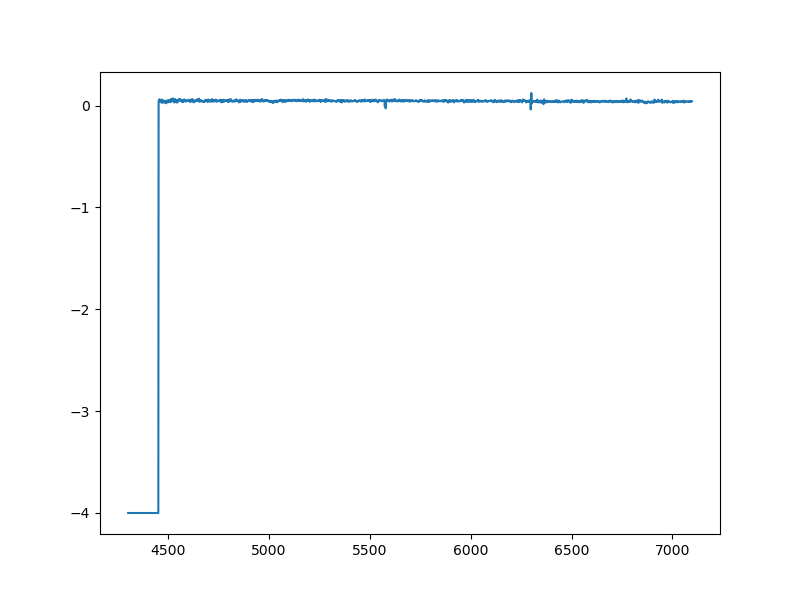

In [57]:
plt.figure(figsize = (8, 6))
plt.plot(wv, spectra[4])

In [29]:
l_OIII_2

5163.241907016047